# E-Commerce Sales Analysis – Exploratory Data Analysis (EDA)

## Objective
Explore sales, revenue, profit, customers, products, categories, geography,
order status, payment methods, shipping methods and time-based trends.

The analysis will identify key business patterns, top-performing segments,
profitability drivers and areas requiring attention.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv(
    "../Dataset/ecommerce_sales_dataset.csv",
    parse_dates=["Order_Date"]
)

df.head()

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,Country,Category,Sub_Category,Product_Name,Unit_Price,Quantity,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,Mexico,Electronics,Smartphones,Xiaomi 13,520.40,7,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,USA,Books & Media,Books,Thinking Fast and Slow,22.59,2,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,Canada,Electronics,Headphones,Bose QC45,241.30,1,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,Japan,Clothing,Women's Wear,Summer Dress,130.90,5,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,France,Clothing,Footwear,Adidas Ultraboost,74.51,3,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 10000
Columns: 26
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          10000 non-null  str           
 1   Order_Date        10000 non-null  datetime64[us]
 2   Year              10000 non-null  int64         
 3   Month             10000 non-null  int64         
 4   Quarter           10000 non-null  str           
 5   Season            10000 non-null  str           
 6   Customer_ID       10000 non-null  str           
 7   Customer_Gender   10000 non-null  str           
 8   Customer_Segment  10000 non-null  str           
 9   Region            10000 non-null  str           
 10  Country           10000 non-null  str           
 11  Category          10000 non-null  str           
 12  Sub_Category      10000 non-null  str           
 13  Product_Name      10000 non-null  str           
 14  Unit_Price

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_Date,10000,2023-04-06 12:20:18.240000,2021-01-05 00:00:00,2022-09-02 00:00:00,2023-05-13 00:00:00,2023-11-24 00:00:00,2024-12-24 00:00:00,NaN
Year,10000.0,2022.7563,2021.0,2022.0,2023.0,2023.0,2024.0,0.878628
Month,10000.0,6.6043,1.0,4.0,7.0,10.0,12.0,3.406799
Unit_Price,10000.0,236.307452,10.01,42.7675,92.495,221.8225,2497.76,380.901351
Quantity,10000.0,2.7313,1.0,1.0,2.0,4.0,10.0,2.038508
Discount,10000.0,0.17675,0.0,0.0,0.15,0.3,0.5,0.16167
Revenue,10000.0,528.43877,5.33,67.2275,164.6,469.9525,19966.5,1154.811538
Cost,10000.0,384.674939,4.85,50.0175,121.395,339.02,15729.67,828.0691
Profit,10000.0,143.763831,-1572.9,9.0075,34.745,118.475,9144.15,420.487992
Profit_Margin_%,10000.0,23.648594,-50.0,13.4975,28.33,39.0825,54.99,21.496639


## Key Business Questions

1. How are Revenue and Profit distributed?
2. Which categories generate the highest Revenue and Profit?
3. Which sub-categories perform best?
4. Which countries and regions contribute the most sales?
5. Which customer segments are most valuable?
6. What are the monthly sales and profit trends?
7. Which products generate the highest Revenue and Profit?
8. What is the order status distribution?
9. Which payment and shipping methods are most commonly used?
10. Which areas show negative or low profitability?

In [9]:
print("Total Revenue:", round(df["Revenue"].sum(), 2))
print("Total Cost:", round(df["Cost"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))

print("Average Revenue per Order:", round(df["Revenue"].mean(), 2))
print("Average Profit per Order:", round(df["Profit"].mean(), 2))

print("Overall Profit Margin:",
      round((df["Profit"].sum() / df["Revenue"].sum()) * 100, 2), "%")

Total Revenue: 5284387.7
Total Cost: 3846749.39
Total Profit: 1437638.31
Average Revenue per Order: 528.44
Average Profit per Order: 143.76
Overall Profit Margin: 27.21 %


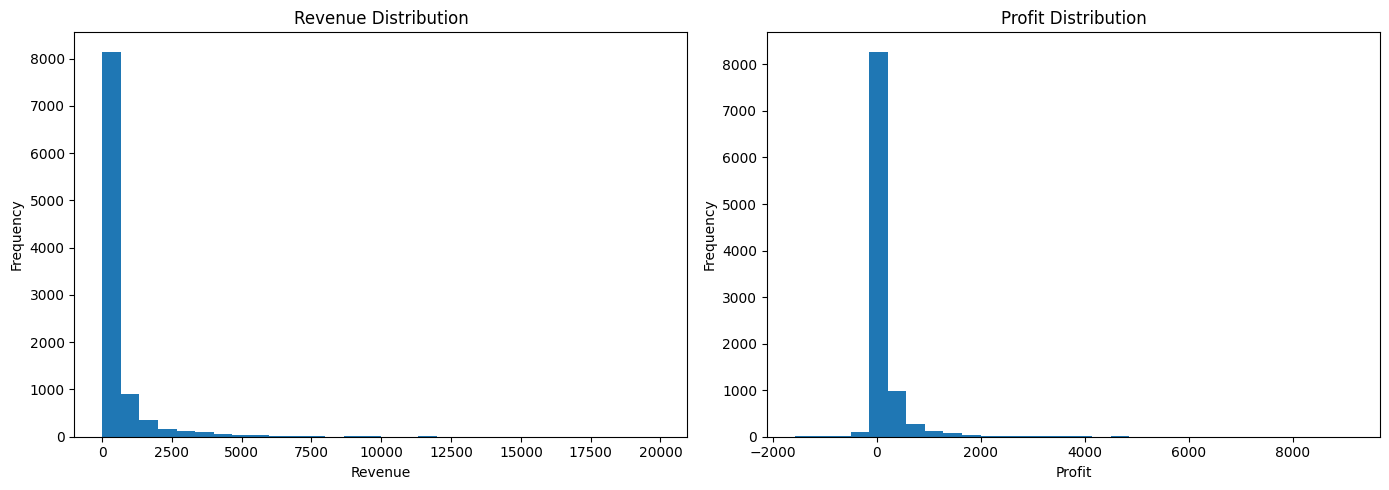

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Revenue"], bins=30)
axes[0].set_title("Revenue Distribution")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["Profit"], bins=30)
axes[1].set_title("Profit Distribution")
axes[1].set_xlabel("Profit")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 1. Category-wise Performance

Analyze Revenue, Profit and Profit Margin across product categories.

In [11]:
category_analysis = (
    df.groupby("Category")
      .agg(
          Orders=("Order_ID", "count"),
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

category_analysis["Profit_Margin_%"] = (
    category_analysis["Profit"] / category_analysis["Revenue"] * 100
).round(2)

category_analysis

,Orders,Revenue,Profit,Profit_Margin_%
Category,,,,
Electronics,1977,3382028.46,925448.15,27.36
Home & Kitchen,2008,892842.02,232421.45,26.03
Clothing,1977,407471.79,115705.29,28.40
Books & Media,2043,386644.46,105037.69,27.17
Beauty & Health,1995,215400.97,59025.73,27.40


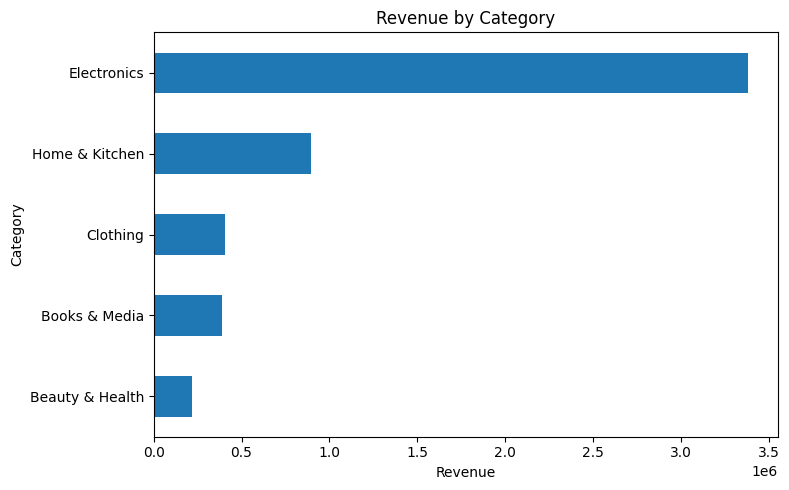

In [12]:
category_analysis["Revenue"].sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Revenue by Category"
)

plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

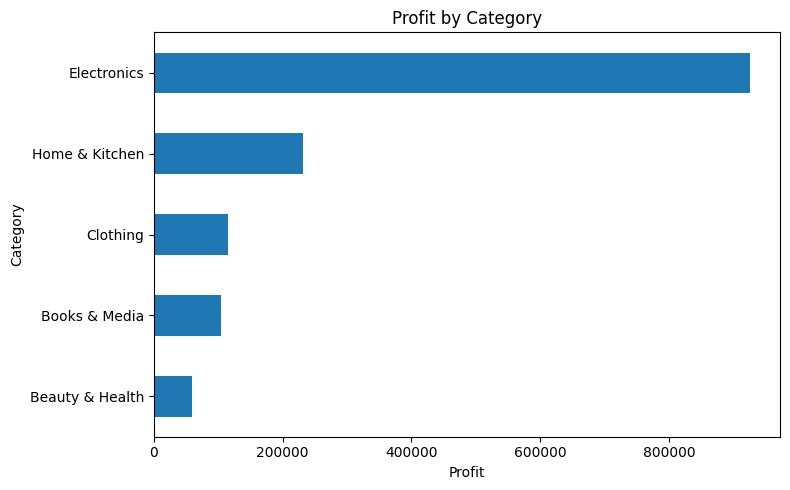

In [13]:
category_analysis["Profit"].sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Profit by Category"
)

plt.xlabel("Profit")
plt.ylabel("Category")
plt.tight_layout()
plt.show()